# PyLHE version 2.0.0 demo

## The LHE File Format

- standardized format to describe events generated in high-energy physics simulations
- widely used in the context of Monte Carlo event generators
- designed to facilitate the exchange of event information between different software packages

### Key Features

- **XML-Based with Fortran mixin**: both human-readable and machine-readable.
- **Event Structure**: contains a series of events, each described by particles and their properties.

### Basic Structure

An LHE file typically consists of the following main components:

1. **Header**: Contains metadata, version and generator information.
2. **Initialization Block**: Describes the initial state of the event, including the incoming beams.
3. **Event Blocks**: Each event is described in its own block, detailing the initial, intermediate, and final state particles.
4. **Weights Block**: Optional block that provides additional information about the event weights.

```xml
<LesHouchesEvents version="1.0">
<header></header>
<init>
beam1id beam2id beam1energy beam2energy pdfg1 pdfg2 pdfs1 pdfs2 idweight nproc
crosssection crosssectionerror crosssectionmaximum pid
...
</init>
<event>
nparticles pid weight scale aqed aqcd
id status mother1 mother2 color1 color2 px py pz E m lifetime spin
...
</event>
...
</LesHouchesEvents>
```


## New since version 1.0.0

- Strict typing checks with MyPy
- Larger test suite
- Sphinx documentation at https://pylhe.readthedocs.io/

  

### IO access via `@classmethod`s `LHEFile.fromstring/fromfile`

In [1]:
from pylhe import LHEFile

mylhe = """
<LesHouchesEvents version="1.0">
<header></header>
<init>
11 -11 100.0 100.0 0 0 0 0 3 1
3.783590 0.001676 0.001569 0
</init>
<event>
6 0 3.783590e-06 200 0.007849 0.1075
11 -1 0 0 0 0 0 0 100.0 100.0 0 0 9.0
-11 -1 0 0 0 0 0 0 -100.0 100.0 0 0 9.0
22 2 1 2 0 0 0 0 0 200 200 0 9.0
2 1 3 0 0 0 48.253308 67.445271 -54.164510 99.050697 0 0 9.0
21 1 3 0 0 0 -1.190913 -12.743630 5.613176 13.975913 0 0 9.0
-2 1 3 0 0 0 -47.062395 -54.701640 48.551333 86.973389 0 0 9.0
</event>
</LesHouchesEvents>
"""
lhef = LHEFile.fromstring(mylhe)
lhef

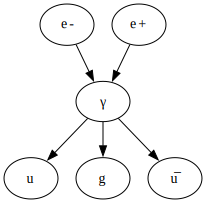

In [2]:
theevent = next(lhef.events)
theevent

### Structured dataclasses instead of deprecated dicts

old dict way

becomes simpler

In [3]:
lhef.init.initInfo.beamA

11

In [4]:
theevent.particles

[LHEParticle(id=11, status=-1, mother1=0, mother2=0, color1=0, color2=0, px=0.0, py=0.0, pz=100.0, e=100.0, m=0.0, lifetime=0.0, spin=9.0),
 LHEParticle(id=-11, status=-1, mother1=0, mother2=0, color1=0, color2=0, px=0.0, py=0.0, pz=-100.0, e=100.0, m=0.0, lifetime=0.0, spin=9.0),
 LHEParticle(id=22, status=2, mother1=1, mother2=2, color1=0, color2=0, px=0.0, py=0.0, pz=0.0, e=200.0, m=200.0, lifetime=0.0, spin=9.0),
 LHEParticle(id=2, status=1, mother1=3, mother2=0, color1=0, color2=0, px=48.253308, py=67.445271, pz=-54.16451, e=99.050697, m=0.0, lifetime=0.0, spin=9.0),
 LHEParticle(id=21, status=1, mother1=3, mother2=0, color1=0, color2=0, px=-1.190913, py=-12.74363, pz=5.613176, e=13.975913, m=0.0, lifetime=0.0, spin=9.0),
 LHEParticle(id=-2, status=1, mother1=3, mother2=0, color1=0, color2=0, px=-47.062395, py=-54.70164, pz=48.551333, e=86.973389, m=0.0, lifetime=0.0, spin=9.0)]

In [5]:
theevent.particles[0].id

11

In [13]:
theevent.mothers(theevent.particles[-1])

[LHEParticle(id=22, status=2, mother1=1, mother2=2, color1=0, color2=0, px=0.0, py=0.0, pz=0.0, e=200.0, m=200.0, lifetime=0.0, spin=9.0)]

In [7]:
print(lhef.tolhe())

<LesHouchesEvents version="1.0">
<header />
<init>
     11    -11  1.0000000e+02  1.0000000e+02     0     0     0     0     3     1
 3.7835900e+00  1.6760000e-03  1.5690000e-03     0

</init>
</LesHouchesEvents>


> ⚠️ **No Events?!:** We already consumed the events `yield`ed by the generator. The generator approach is great for large files or event generation streams, but what if we just want to modify the/some events in a list-like fashion.

In [8]:
lhef = LHEFile.fromstring(mylhe, generator=False)

### New output/write to file `LHEFile.tofile/tolhe`

In [9]:
lhef.tofile("myevents.lhe.gz")
print(lhef.tolhe())

<LesHouchesEvents version="1.0">
<header />
<init>
     11    -11  1.0000000e+02  1.0000000e+02     0     0     0     0     3     1
 3.7835900e+00  1.6760000e-03  1.5690000e-03     0

</init>
<event>
  6      0  3.7835900000e-06  2.0000000000e+02  7.8490000000e-03  1.0750000000e-01
   11  -1   0   0   0   0  0.00000000e+00  0.00000000e+00  1.00000000e+02  1.00000000e+02  0.00000000e+00  0.0000e+00  9.0000e+00
  -11  -1   0   0   0   0  0.00000000e+00  0.00000000e+00 -1.00000000e+02  1.00000000e+02  0.00000000e+00  0.0000e+00  9.0000e+00
   22   2   1   2   0   0  0.00000000e+00  0.00000000e+00  0.00000000e+00  2.00000000e+02  2.00000000e+02  0.0000e+00  9.0000e+00
    2   1   3   0   0   0  4.82533080e+01  6.74452710e+01 -5.41645100e+01  9.90506970e+01  0.00000000e+00  0.0000e+00  9.0000e+00
   21   1   3   0   0   0 -1.19091300e+00 -1.27436300e+01  5.61317600e+00  1.39759130e+01  0.00000000e+00  0.0000e+00  9.0000e+00
   -2   1   3   0   0   0 -4.70623950e+01 -5.47016400e+01  4.855133

In [10]:
!zcat myevents.lhe.gz

<LesHouchesEvents version="1.0">
<header />
<init>
     11    -11  1.0000000e+02  1.0000000e+02     0     0     0     0     3     1
 3.7835900e+00  1.6760000e-03  1.5690000e-03     0

</init>
<event>
  6      0  3.7835900000e-06  2.0000000000e+02  7.8490000000e-03  1.0750000000e-01
   11  -1   0   0   0   0  0.00000000e+00  0.00000000e+00  1.00000000e+02  1.00000000e+02  0.00000000e+00  0.0000e+00  9.0000e+00
  -11  -1   0   0   0   0  0.00000000e+00  0.00000000e+00 -1.00000000e+02  1.00000000e+02  0.00000000e+00  0.0000e+00  9.0000e+00
   22   2   1   2   0   0  0.00000000e+00  0.00000000e+00  0.00000000e+00  2.00000000e+02  2.00000000e+02  0.0000e+00  9.0000e+00
    2   1   3   0   0   0  4.82533080e+01  6.74452710e+01 -5.41645100e+01  9.90506970e+01  0.00000000e+00  0.0000e+00  9.0000e+00
   21   1   3   0   0   0 -1.19091300e+00 -1.27436300e+01  5.61317600e+00  1.39759130e+01  0.00000000e+00  0.0000e+00  9.0000e+00
   -2   1   3   0   0   0 -4.70623950e+01 -5.47016400e+01  4.855133

## dict -> dataclass: Parse don't validate! [1]

- Don’t just check if data is valid instead transform it into a well-typed structure.
- Make invalid states unrepresentable through type-safe parsing.

[1] https://lexi-lambda.github.io/blog/2019/11/05/parse-don-t-validate/


### Dataclasses and strict typing instead of loose dicts

The old layout:
- inherits from `dict`
- weird `fieldnames`
- `args` and `kwargs`
- ugly hypothetical `dict` typing

In [11]:
class LHEInit_old(dict):
    """Store the <init> block as dict."""

    # weightgroup : dict[str, dict[str, dict[str, Union[dict[str, str], str, int]]]]
    fieldnames = ["initInfo", "procInfo", "weightgroup", "LHEVersion"]

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

The new layout below:
- members are strictly typed now
- properly type hint => better LLM/coding agent integration
- autocompletion works better in Jupyter Notebooks and IDEs
- data is guaranteed to exist in correct format unlike dicts
- MyPy found bugs in the old code while doing this (e.g. missing `None` checks)
- members have documentation strings
- data is printed nicely without extra effort

In [12]:
from dataclasses import dataclass

from pylhe import LHEInitInfo, LHEProcInfo


@dataclass
class LHEInit_new:
    """Store the <init> block as a dataclass."""

    initInfo: LHEInitInfo
    """Init information"""
    procInfo: list[LHEProcInfo]
    """Process information"""

### Next steps

- release 1.0.0
- publish JOSS paper

## Further interactive examples to explore

- [Analyze LHE file and plot `hist`-ograms →](01_zpeak.ipynb)
- [Filter LHE events based on kinematic cuts →](02_filter_events_example.ipynb)
- [Simple Monte Carlo LHE event generator →](03_write_monte_carlo_example.ipynb)
- [Conversion/interface to `awkward` arrays →](91_awkward_example.ipynb)
- [Parallel processing of LHE files →](92_multiple_files.ipynb)
- [Parquet Cache →](93_parquet_cache.ipynb)